# Import necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Importing the dataset using pandas dataframe

In [2]:
dataset = pd.read_csv('Salary_Data_larger.csv')
dataset.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [3]:
dataset.shape

(6704, 6)

### Checking dataset type and various info

In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB


In [5]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,6702.0,33.620859,7.614633,21.0,28.0,32.0,38.0,62.0
Years of Experience,6701.0,8.094687,6.059003,0.0,3.0,7.0,12.0,34.0
Salary,6699.0,115326.964771,52786.183911,350.0,70000.0,115000.0,160000.0,250000.0


## checking for missing values as they can worsen the predictions and hamper in model training

In [6]:
missing_data = dataset.isnull().sum()
print(missing_data)

Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64


In [7]:
dataset.dropna(inplace=True)

In [8]:
missing_data = dataset.isnull().sum()
print(missing_data)

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64


### Creating a copy of the main dataset -> not necessary but makes it flexible to work and fix issues

In [9]:
dataset_copy = dataset.copy()

dataset_copy.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


### Converting object types to string so that ML model can work -> most models need int/float only but as I am using CatBoost, it can work with string, float, and interger types.

In [10]:
dataset_copy["Gender"] = dataset_copy["Gender"].astype("string")
dataset_copy["Education Level"] = dataset_copy["Education Level"].astype("string")
dataset_copy["Job Title"] = dataset_copy["Job Title"].astype("string")

In [11]:
dataset_copy.dtypes

Age                           float64
Gender                 string[python]
Education Level        string[python]
Job Title              string[python]
Years of Experience           float64
Salary                        float64
dtype: object

### Checking for duplicate values in the dataset as they can give exceptional training performance and worse testing results.

In [12]:
dataset_copy.duplicated().sum()

np.int64(4911)

In [13]:
dataset_copy = dataset_copy.drop_duplicates()

In [14]:
dataset_copy.duplicated().sum()

np.int64(0)

### Simplifying the string values for the model

In [15]:
dataset_copy["Gender"] = dataset_copy["Gender"].str.lower().str.strip()
dataset_copy["Education Level"] = dataset_copy["Education Level"].str.lower().str.strip()
dataset_copy["Job Title"] = dataset_copy["Job Title"].str.lower().str.strip()

In [16]:
dataset_copy.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,male,bachelor's,software engineer,5.0,90000.0
1,28.0,female,master's,data analyst,3.0,65000.0
2,45.0,male,phd,senior manager,15.0,150000.0
3,36.0,female,bachelor's,sales associate,7.0,60000.0
4,52.0,male,master's,director,20.0,200000.0


### Here, I am fixing the education level columns value's as they are a bit irregular. For easier model understanding cleaning is done here.

In [17]:
dataset_copy["Education Level"] = dataset_copy["Education Level"].replace("phd","PhD")
dataset_copy["Education Level"] = dataset_copy["Education Level"].replace("master's degree","Master")
dataset_copy["Education Level"] = dataset_copy["Education Level"].replace("master's","Master")
dataset_copy["Education Level"] = dataset_copy["Education Level"].replace("bachelor's degree","Bachelor")
dataset_copy["Education Level"] = dataset_copy["Education Level"].replace("bachelor's","Bachelor")
dataset_copy["Education Level"] = dataset_copy["Education Level"].replace("high school","High School")

In [18]:
dataset_copy.shape

(1787, 6)

### Final veiw of the dataset before feeding the data inside model

In [19]:
dataset_copy.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,male,Bachelor,software engineer,5.0,90000.0
1,28.0,female,Master,data analyst,3.0,65000.0
2,45.0,male,PhD,senior manager,15.0,150000.0
3,36.0,female,Bachelor,sales associate,7.0,60000.0
4,52.0,male,Master,director,20.0,200000.0


## Dataset split for model training (single split checking)

In [23]:
x = dataset_copy.drop(columns=["Salary"])
y = dataset_copy["Salary"]

In [24]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

### Importing catboost model and assigning the categorical columns

In [27]:
from catboost import CatBoostRegressor

cat_features = ["Gender", "Education Level", "Job Title"]

### Default CatBoostRegressor model is used.

In [28]:
model = CatBoostRegressor()

In [29]:
model.fit(
    x_train,
    y_train,
    cat_features=cat_features,
    verbose=100
)

Learning rate set to 0.043319
0:	learn: 49831.4902915	total: 235ms	remaining: 3m 54s
100:	learn: 18017.7845262	total: 3.07s	remaining: 27.3s
200:	learn: 15811.4394141	total: 6.17s	remaining: 24.5s
300:	learn: 14480.7059105	total: 9.07s	remaining: 21.1s
400:	learn: 13550.8980290	total: 12.5s	remaining: 18.7s
500:	learn: 12826.3757906	total: 15.3s	remaining: 15.2s
600:	learn: 12188.6012288	total: 18.4s	remaining: 12.2s
700:	learn: 11711.7311553	total: 21.3s	remaining: 9.09s
800:	learn: 11227.6695465	total: 24.5s	remaining: 6.08s
900:	learn: 10840.3066758	total: 27.4s	remaining: 3.01s
999:	learn: 10463.4348396	total: 30.2s	remaining: 0us


In [30]:
predictions = model.predict(x_test)

### Performance measurement of the model

In [31]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print(r2_score(y_test, predictions))
print(mean_absolute_error(y_test, predictions))
print(mean_squared_error(y_test, predictions))

0.8983603428550143
11576.081469158866
278486593.41453946


### Input function for manual testing

In [32]:
def predict_salary(age, gender, education, job_title, experience):
    
    
    user_data = pd.DataFrame({
        "Age": [age],
        "Gender": [gender.lower().strip()],
        "Education Level": [education],
        "Job Title": [job_title.lower().strip()],
        "Years of Experience": [experience]
    })
    
    prediction = model.predict(user_data)[0]
    
    return round(prediction, 2)

In [33]:
# use it for making predictions 

predict_salary(
    age=46,
    gender="Male",
    education="PhD",  # Bachelor, Master, PhD
    job_title="Manager",
    experience=2
)

np.float64(58072.63)

### SHAP Analysis -> it shows what's in the dataset is responsible for prediction

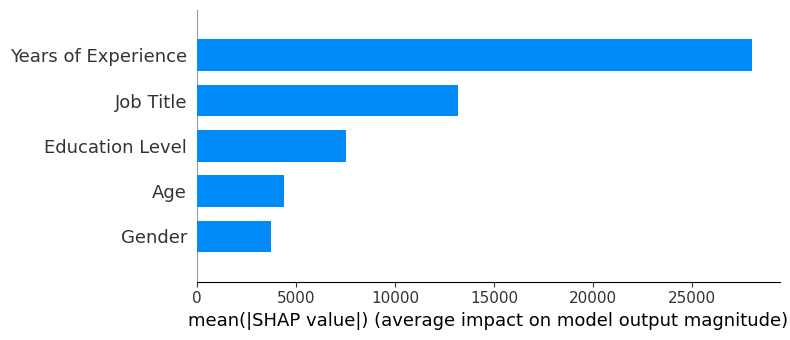

In [34]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(x_test)
shap.summary_plot(shap_values, x_test, plot_type="bar")

### Cross validation for checking model's performance on the entire dataset (better than single split analysis)

In [ ]:
from catboost import Pool, cv

cat_features = ["Gender", "Education Level", "Job Title"]

# using 5-fold --> 4 fold contains data for training and 1 fold for testing, and repeats 5 times 
# --> so that all data gets used for both training and testing across the folds
train_pool = Pool(
    data=dataset_copy.drop("Salary", axis=1), 
    label=dataset_copy["Salary"],
    cat_features=cat_features
)

cv_results = cv(
    pool=train_pool,
    params={
        "loss_function": "RMSE",   
        "eval_metric": "R2"       
    },
    fold_count=5
)

print(cv_results.tail())

Training on fold [0/5]
0:	learn: -4.4662384	test: -4.6506262	best: -4.6506262 (0)	total: 41ms	remaining: 41s
1:	learn: -4.1776598	test: -4.3432323	best: -4.3432323 (1)	total: 55.7ms	remaining: 27.8s
2:	learn: -3.9143339	test: -4.0668484	best: -4.0668484 (2)	total: 75ms	remaining: 24.9s
3:	learn: -3.6548841	test: -3.7913195	best: -3.7913195 (3)	total: 106ms	remaining: 26.4s
4:	learn: -3.4075624	test: -3.5397832	best: -3.5397832 (4)	total: 133ms	remaining: 26.5s
5:	learn: -3.1767456	test: -3.2998139	best: -3.2998139 (5)	total: 163ms	remaining: 27s
6:	learn: -2.9702699	test: -3.0837663	best: -3.0837663 (6)	total: 187ms	remaining: 26.6s
7:	learn: -2.7740091	test: -2.8809977	best: -2.8809977 (7)	total: 199ms	remaining: 24.7s
8:	learn: -2.5892142	test: -2.6895248	best: -2.6895248 (8)	total: 207ms	remaining: 22.8s
9:	learn: -2.3977998	test: -2.4939126	best: -2.4939126 (9)	total: 219ms	remaining: 21.7s
10:	learn: -2.2280847	test: -2.3204019	best: -2.3204019 (10)	total: 243ms	remaining: 21.8s
1

In [64]:
best_r2 = cv_results["test-R2-mean"].max()
print(best_r2)

0.8995992964184785


### For deployment..

In [35]:
x.head()

,Age,Gender,Education Level,Job Title,Years of Experience
0,32.0,male,Bachelor,software engineer,5.0
1,28.0,female,Master,data analyst,3.0
2,45.0,male,PhD,senior manager,15.0
3,36.0,female,Bachelor,sales associate,7.0
4,52.0,male,Master,director,20.0


In [66]:
from catboost import CatBoostRegressor

model = CatBoostRegressor(loss_function="RMSE")
model.fit(x, y, cat_features=[1,2,3])

model.save_model("salary_model.cbm")

Learning rate set to 0.044876
0:	learn: 49951.2784731	total: 23.9ms	remaining: 23.9s
1:	learn: 48541.2268793	total: 51.8ms	remaining: 25.9s
2:	learn: 47058.5184430	total: 78.2ms	remaining: 26s
3:	learn: 45749.3555724	total: 104ms	remaining: 26s
4:	learn: 44645.0382827	total: 122ms	remaining: 24.4s
5:	learn: 43482.3795739	total: 140ms	remaining: 23.2s
6:	learn: 42352.1250966	total: 170ms	remaining: 24.2s
7:	learn: 41242.6773984	total: 204ms	remaining: 25.4s
8:	learn: 40198.3238856	total: 251ms	remaining: 27.6s
9:	learn: 39210.6440027	total: 288ms	remaining: 28.5s
10:	learn: 38282.3772696	total: 318ms	remaining: 28.6s
11:	learn: 37406.7534429	total: 347ms	remaining: 28.5s
12:	learn: 36535.8457551	total: 373ms	remaining: 28.3s
13:	learn: 35756.1201437	total: 402ms	remaining: 28.3s
14:	learn: 35036.9059570	total: 429ms	remaining: 28.2s
15:	learn: 34329.5948571	total: 479ms	remaining: 29.5s
16:	learn: 33683.6368465	total: 514ms	remaining: 29.7s
17:	learn: 33065.0270291	total: 543ms	remainin

In [36]:
model = CatBoostRegressor()
model.load_model("salary_model.cbm")

sample = [[30, "male", "Master", "software engineer", 5]]

prediction = model.predict(sample)

print("Predicted Salary:", prediction[0])

Predicted Salary: 107849.3580670287
